Part 1 — Data Understanding & Exploration

In [11]:
#1.Load the dataset using Pandas
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv('/content/healthcare_dataset.csv')

In [12]:
#2.Explore dataset structure:
data.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [4]:
df=data.shape
print('The shape of the dataset',df)

The shape of the dataset (6000, 7)


In [13]:
df=data.dtypes
print("coloums type of the dataset",df)

coloums type of the dataset patient_id                   int64
age                          int64
bmi                        float64
exercise_hours_per_week    float64
smoker                       int64
blood_pressure             float64
diabetes                     int64
dtype: object


In [10]:
print(data.isnull().sum())

patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64


In [15]:
#3.Perform basic statistical analysis
data.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


### 4. Visualize relationships between features and diabetes

/tmp/ipykernel_2958/2841105040.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='diabetes', y='age', data=data, palette='viridis')


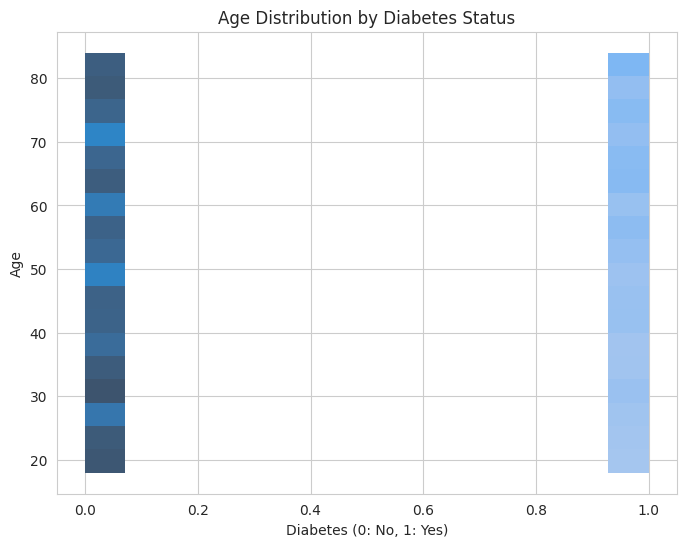

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age vs Diabetes
plt.figure(figsize=(8, 6))
sns.histplot(x='diabetes', y='age', data=data, palette='viridis')
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

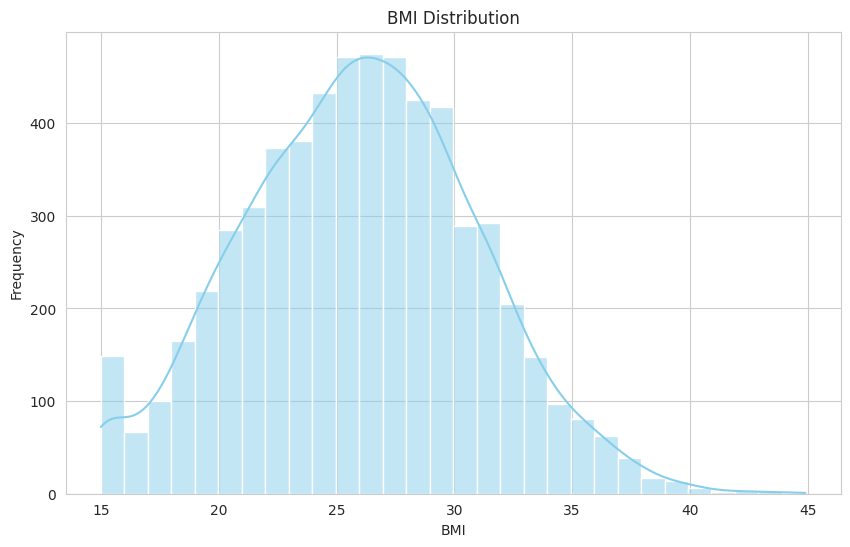

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], kde=True, bins=30, color='skyblue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_2958/2762334806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diabetes', y='exercise_hours_per_week', data=data, palette='plasma')


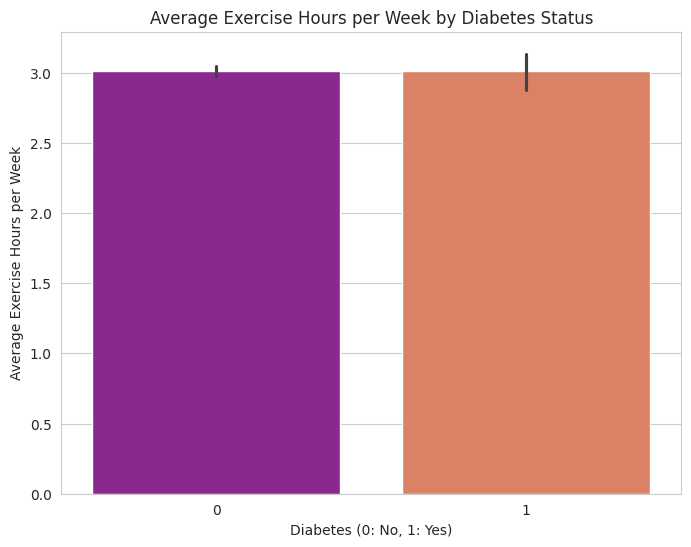

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(x='diabetes', y='exercise_hours_per_week', data=data, palette='plasma')
plt.title('Average Exercise Hours per Week by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Average Exercise Hours per Week')
plt.show()

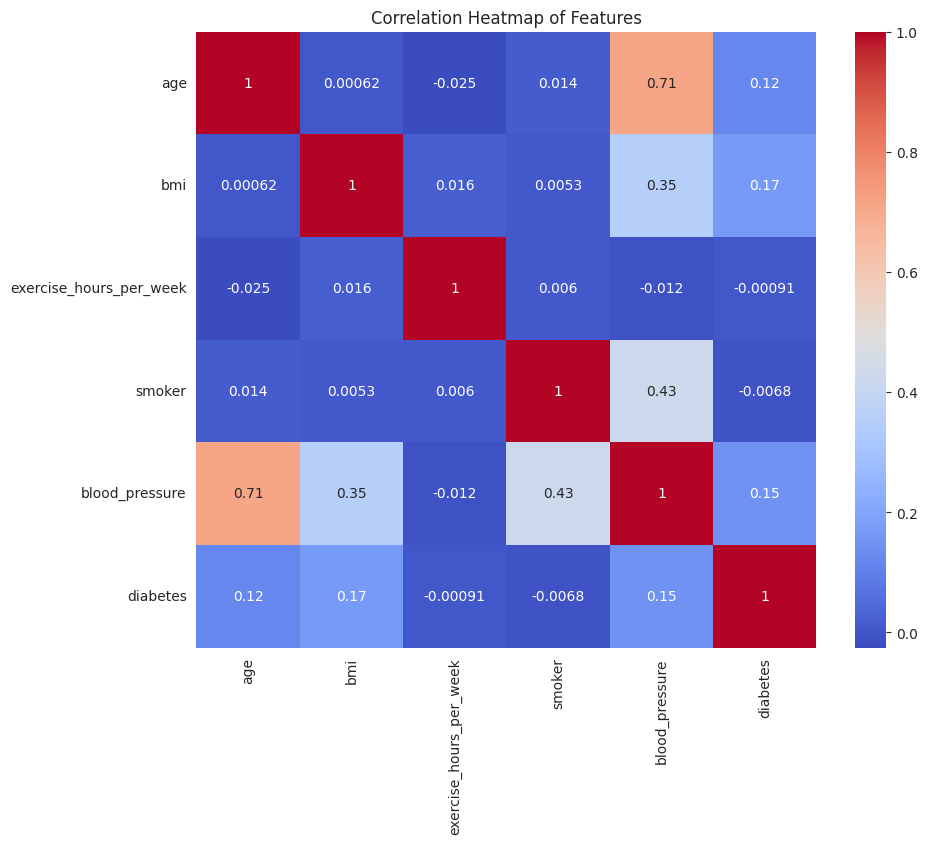

In [21]:
plt.figure(figsize=(10, 8))
correlation_matrix = data.drop(columns=['patient_id']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

Part 2 — Machine Learning Classification Model

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Separate features (X) and target variable (y)
# Drop 'patient_id' as it's an identifier and not a predictive feature
X = data.drop(columns=['diabetes'])
y = data['diabetes']

In [23]:
# 2. Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTrain-Test Split:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Train-Test Split:
X_train shape: (4800, 6)
X_test shape: (1200, 6)
y_train shape: (4800,)
y_test shape: (1200,)


In [24]:
# 3. Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# 4. Train a Logistic Regression classifier
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [26]:
# 5. Generate predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [27]:
# 6. Evaluate model performance
print("\n--- Model Evaluation ---")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


--- Model Evaluation ---
Accuracy: 0.9100

Confusion Matrix:
[[1092    0]
 [ 108    0]]


In [30]:

# Classification Report (includes Precision, Recall, F1 Score)
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)



Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1092
           1       0.00      0.00      0.00       108

    accuracy                           0.91      1200
   macro avg       0.46      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Part 3 — Neural Network Model

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Create a Sequential neural network model
model_nn = Sequential()

In [33]:
# 2. Add layers:
# a. Input layer: Number of input features is X_train_scaled.shape[1]
model_nn.add(Dense(units=32, activation='relu', input_shape=(X_train.shape[1],)))

# b. Hidden layers (e.g., one or two more dense layers)
model_nn.add(Dense(units=16, activation='relu'))

# c. Output layer: 1 unit for binary classification, sigmoid activation
model_nn.add(Dense(units=1, activation='sigmoid'))

# Display model summary
print("\n--- Neural Network Model Summary ---")
model_nn.summary()


--- Neural Network Model Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# 3. Compile model:
# a. Adam optimizer
# b. Binary crossentropy loss (for binary classification)
model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [37]:

# 4. Train the model
# Using 50 epochs and a batch size of 32 for demonstration
# You might need to adjust these for better performance

history = model_nn.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)




Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9112 - loss: 0.2499 - val_accuracy: 0.9094 - val_loss: 0.2950
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9107 - loss: 0.2505 - val_accuracy: 0.9083 - val_loss: 0.2946
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9109 - loss: 0.2500 - val_accuracy: 0.9083 - val_loss: 0.2951
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9112 - loss: 0.2494 - val_accuracy: 0.9073 - val_loss: 0.2950
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9120 - loss: 0.2499 - val_accuracy: 0.9062 - val_loss: 0.2954
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9109 - loss: 0.2497 - val_accuracy: 0.9073 - val_loss: 0.2944
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9109 - loss: 0.2483 - val_accuracy: 0.9052 - val_loss: 0.2957
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9115 - loss: 0.2501 - val_accuracy: 0.

In [38]:
# 5. Evaluate performance on test data
print("\n--- Neural Network Model Evaluation ---")
loss, accuracy_nn = model_nn.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {accuracy_nn:.4f}")
print(f"Test Loss: {loss:.4f}")

y_pred_nn_proba = model_nn.predict(X_test_scaled, verbose=0)
y_pred_nn = (y_pred_nn_proba > 0.5).astype(int)

# Confusion Matrix
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)
print("\nConfusion Matrix (Neural Network):")
print(conf_matrix_nn)

# Classification Report
class_report_nn = classification_report(y_test, y_pred_nn)
print("\nClassification Report (Neural Network):")
print(class_report_nn)



--- Neural Network Model Evaluation ---
Test Accuracy: 0.9058
Test Loss: 0.3376

Confusion Matrix (Neural Network):
[[1084    8]
 [ 105    3]]

Classification Report (Neural Network):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1092
           1       0.27      0.03      0.05       108

    accuracy                           0.91      1200
   macro avg       0.59      0.51      0.50      1200
weighted avg       0.85      0.91      0.87      1200



### Accuracy Difference

Based on the execution results:

*   **Logistic Regression Accuracy:** `0.9100`
*   **Neural Network Accuracy:** `0.9058`

In this particular instance, the Logistic Regression model achieved a slightly higher accuracy than the Neural Network. However, it's crucial to look beyond just accuracy, especially considering the severe class imbalance evident in the confusion matrices (many non-diabetic cases, very few diabetic cases predicted correctly by Logistic Regression).

The Logistic Regression model predicted all instances as class 0 (no diabetes), resulting in 100% recall for class 0 but 0% recall for class 1. This means it failed to identify any actual diabetes cases.

The Neural Network, while having a slightly lower overall accuracy, did manage to predict 3 instances of diabetes correctly (True Positives), which is a better outcome for identifying the minority class, although still very low.

### Strengths of Machine Learning Models (e.g., Logistic Regression)

*   **Interpretability:** Logistic Regression is highly interpretable. The coefficients directly indicate the impact and direction (positive or negative) of each feature on the log-odds of the target variable. This makes it easier to understand *why* a particular prediction was made.
*   **Computational Efficiency:** They are generally faster to train and make predictions, especially on smaller datasets.
*   **Less Data Hungry:** They can perform well even with relatively smaller datasets, unlike neural networks that often require large amounts of data to generalize effectively.
*   **Simplicity:** Simpler to implement and understand, making them a good baseline or first choice for many classification problems.
*   **Less Prone to Overfitting (with regularization):** With appropriate regularization, logistic regression can be less prone to overfitting compared to complex neural networks, especially when data is limited.

### Strengths of Neural Networks

*   **Ability to Learn Complex Patterns:** Neural networks, especially deep ones, excel at capturing highly complex, non-linear relationships and intricate patterns within data that simpler models might miss.
*   **Feature Learning:** They can automatically learn relevant features from raw data, reducing the need for extensive manual feature engineering.
*   **Scalability with Data:** Their performance often improves significantly with more data, making them ideal for large datasets.
*   **Versatility:** Can be adapted for various tasks, including image recognition, natural language processing, and time series analysis, by changing their architecture.
*   **Handling High-Dimensional Data:** They can effectively process datasets with a very large number of features.

### Limitations of Both Approaches

#### Logistic Regression Limitations

*   **Linearity Assumption:** Assumes a linear relationship between features and the log-odds of the target variable. If the true relationship is complex and non-linear, performance may suffer.
*   **Difficulty with Complex Interactions:** Struggles to capture complex interactions between features without explicit feature engineering.
*   **Not Ideal for Very Large Datasets:** While efficient, their performance gain might plateau on very large and complex datasets where deeper patterns exist.
*   **Feature Engineering Dependent:** Requires significant upfront feature engineering to extract meaningful insights if raw features are not directly informative.

#### Neural Network Limitations

*   **"Black Box" Nature:** Often lack interpretability. It's difficult to understand *why* a neural network makes a particular prediction due to its complex, non-linear structure.
*   **Data Hungry:** Typically require large amounts of labeled data to train effectively and avoid overfitting.
*   **Computational Cost:** Training can be computationally expensive and time-consuming, requiring powerful hardware (GPUs).
*   **Hyperparameter Tuning:** Highly sensitive to hyperparameter choices (e.g., number of layers, neurons, learning rate, activation functions), which can be challenging to optimize.
*   **Overfitting Risk:** Can easily overfit to training data if not properly regularized or if the dataset is too small relative to model complexity.